In [1]:
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.patches as patches
from scipy.signal import convolve2d
from skimage.io import imread

In [2]:
rootfolder = '..'

Define the function to compute the kernel given the weights and the degree of the polynomial

In [3]:
def compute_2D_LPA_kernel(w, N):
    # compute the 2D LPA kernel for a given weights and polynomial degree
    # input:
    #   w: matrix containing the weights for the local LS problem
    #   N: degree of the polynomial approximation
    # return:
    #   g: the computed LPA kernel

    # window size is the lenght of the weight vector
    r, c = w.shape
    M = r*c

    # create the matrix T
    tx = np.linspace(0, 1, c)
    ty = np.linspace(0, 1, r)
    tx, ty = np.meshgrid(tx, ty)
    tx = tx.reshape(-1)
    ty = ty.reshape(-1)
    T = np.zeros((M,(N+1)**2))
    cnt = 0
    for i in range(N+1):
        for j in range(N-i+1):
            if i==0 and j==0:
                T[:, cnt] = np.ones(M)
            else:
                T[:, cnt] = tx**i * ty**j
            cnt = cnt + 1
    T = T[:, :cnt]

    # unroll the matrix of the weights
    w = w.reshape(-1)

    # generate the inverse of weights
    winv = [1 / w_i if w_i != 0 else 0 for w_i in w]
    # set to zero weights that are inf
    winv = [0 if w_i == float('inf') else w_i for w_i in winv]

    # define the weight matrix
    W = np.diag(w)
    Winv = np.diag(winv)

    # comput the qr decomposition of WT
    Q, R = np.linalg.qr(W @ T)

    # define Qtilde
    Qtilde = Winv @ Q

    # adjust Qtilde with the weights matrix squared
    W2Qtilde = (W @ W) @ Qtilde

    # select the central row of W2Qtilde
    row = int(r/2)*c + int(c/2)
    
    # compute the kernel
    g_bar = np.zeros(M)
    for i in range(Qtilde.shape[1]):
        g_bar = g_bar + Qtilde[row, i] * W2Qtilde[:, i]

    # reshape the kernel in a matrix
    g_bar = g_bar.reshape(r, c)

    # flipping, since it is used in convolution
    g = np.flip(g_bar)
    
    return g

Load the image and add the noise

In [4]:
img = imread(f'{rootfolder}/data/cameraman.png') / 255

sigma_noise = 20/255
noisy_img = img + np.random.normal(size=img.shape) * sigma_noise

psnr_noisy = 10 * np.log10(1 / np.mean((img - noisy_img)**2))

Text(0.5, 1.0, 'Noisy image, PSNR = 22.08')

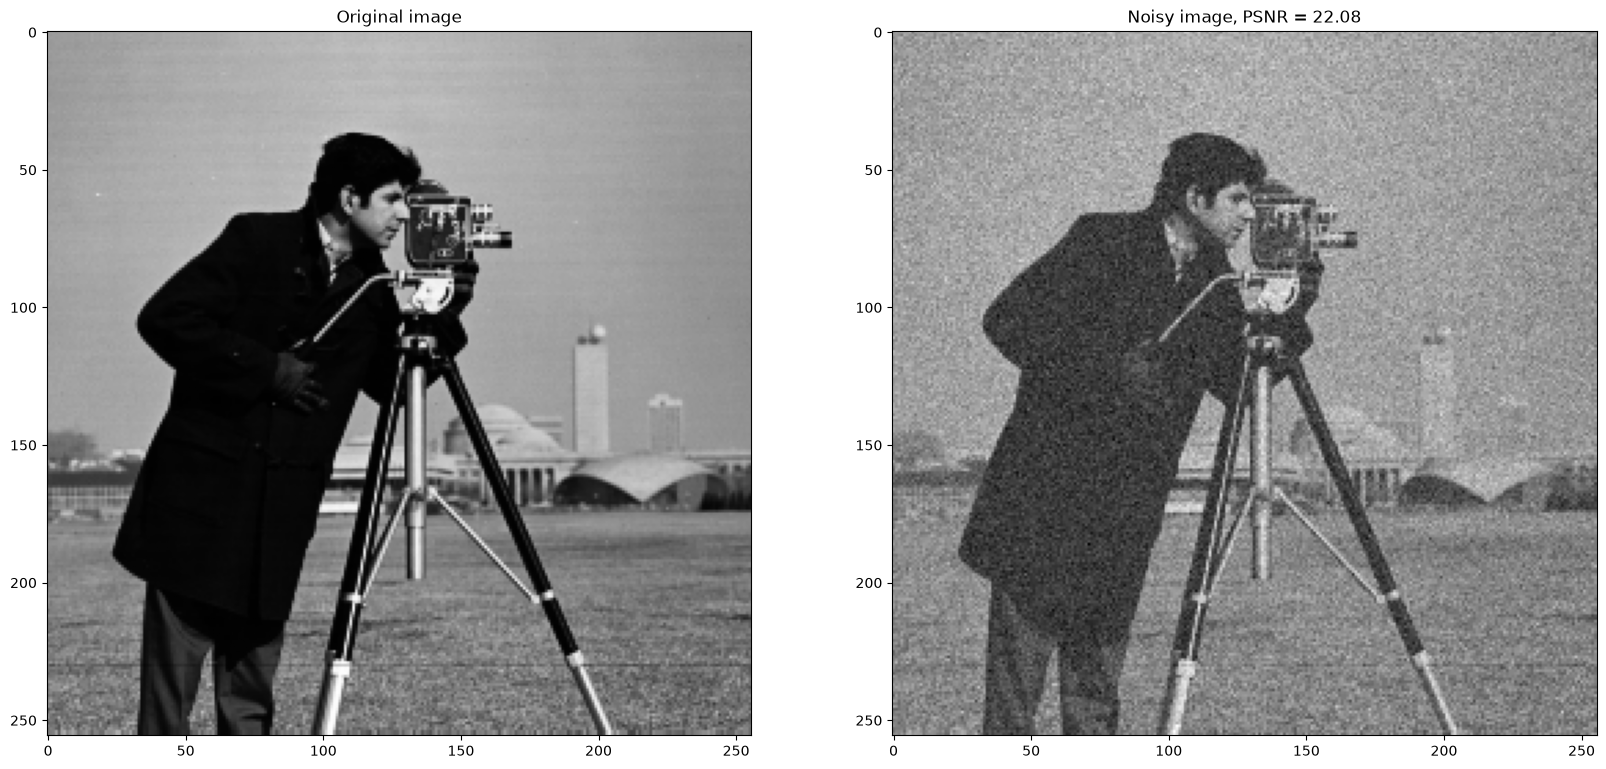

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
ax[0].imshow(img, cmap='gray')
ax[0].set_title('Original image')

ax[1].imshow(noisy_img, cmap='gray')
ax[1].set_title(f'Noisy image, PSNR = {psnr_noisy:.2f}')

LPA-ICI 2D
----------
Set the LPA-ICI parameters

In [6]:
# maximum degree of polynomial used for fitting
N = 5

# parameter for the confidence intervals in the ICI rule
Gamma = 2

# set all the scale values
hmax = 21
all_h = np.arange(2, hmax + 1)

Generate the LPA kernels for all the scales. Use centered weights.


In [7]:
all_g = []
for i, h in enumerate(all_h):
    # define the weights for the scale h symmetric
    h = all_h[i]
    # the kernel size is 2*h + 1, since we want to consider a window of h pixels on each side of the central pixel
    M = 2*h + 1
    w = np.ones((M, M))

    # compute and store the kernel g
    all_g.append(compute_2D_LPA_kernel(w, N))

Initialize all the variables for the ICI rule

In [8]:
# initialize the estimate for each scale
yhat = np.zeros((img.shape))

# initialize the vector containing the best scale for each sample
best_scale = np.zeros(shape=yhat.shape)

# initialize the lower and upper bound matrices
lower_bounds = -np.inf * np.ones(shape=yhat.shape)
upper_bounds = np.inf * np.ones(shape=yhat.shape)

Loop over all the scales

In [9]:
for i, h in enumerate(all_h):
    g = all_g[i]

    # compute the estimate for the scale h
    yhat_h = convolve2d(noisy_img, g, mode='same', boundary='symm')

    std_h = sigma_noise * np.linalg.norm(g)

    # compute the lower and upper bound of the confidence interval for the scale h
    lb = yhat_h - Gamma * std_h
    ub = yhat_h + Gamma * std_h

    # update the lower and upper bounds
    lower_bounds = np.maximum(lower_bounds, lb)
    upper_bounds = np.minimum(upper_bounds, ub)
    
    # identify for which samples h is the best scale according to the ICI rule and update the best_scale vector accordingly
    for j in range(yhat.shape[0]):
        for k in range(yhat.shape[1]):
            if (upper_bounds[j, k] < lower_bounds[j, k] and best_scale[j, k] == 0):
                # if the intersection fails at the first scale, there is no previous estimate available
                if i == 0:
                    best_scale[j, k] = h
                    yhat[j, k] = yhat_h[j, k]
                # the current scale is too large, so we select the previous one as the best scale and we keep the previous estimate
                else:
                    # select the previous scale as the best scale
                    best_scale[j, k] = all_h[i - 1]
                    # keep the previous estimate
                    yhat[j, k] = yhat_old[j, k]
    
    yhat_old = yhat_h.copy()

# recompute the estimate for the largest scale
yhat_h = convolve2d(noisy_img, all_g[-1], mode='same', boundary='symm')
# update the estimate for the samples for which the ICI rule never failed
for i in range(best_scale.shape[0]):
    for j in range(best_scale.shape[1]):
        # samples for which the ICI rule fails have best_scale equal to 0
        if best_scale[i, j] == 0:
            # use the largest scale as the best scale
            best_scale[i, j] = all_h[-1]
            # update the estimate for the samples for which the ICI rule fails
            yhat[i, j] = yhat_h[i, j]

Compute the PSNR

In [10]:
psnr = 10 * np.log10(1 / np.mean((img - yhat)**2))

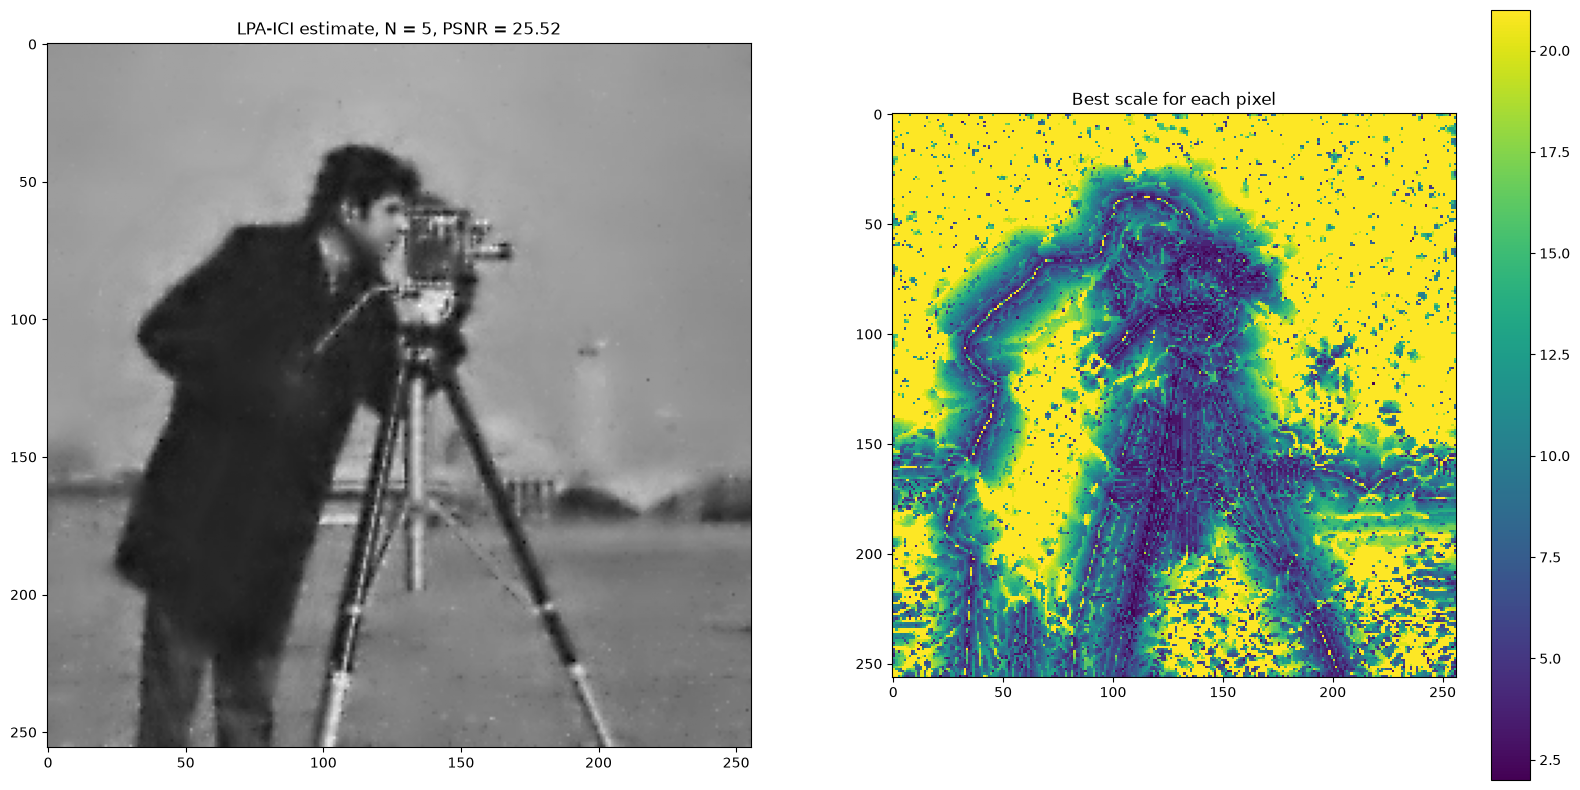

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
ax[0].imshow(yhat, cmap='gray')
ax[0].set_title(f'LPA-ICI estimate, N = {N}, PSNR = {psnr:.2f}')

ax[1].imshow(best_scale)
ax[1].set_title('Best scale for each pixel')
fig.colorbar(ax[1].pcolormesh(best_scale), ax=ax[1])

Anisotropic LPA-ICI
------------------------
Set the parameters


In [12]:
# maximum degree of polynomial used for fitting
N = 1

# parameter for the confidence intervals in the ICI rule
Gamma = 2

# set all the scale values
hmax = 21
all_h = np.arange(1, hmax + 1)

# set all the direction values
all_theta = np.arange(4)

Generate the LPA kernels for all the scales and all the directions

In [13]:
all_g = []

for theta in all_theta:
    all_g_theta = []

    for i, h in enumerate(all_h):
        # define the weights for the scale h and the direction theta
        w = np.zeros((2*h + 1, 2*h + 1))

        if theta == 0:
            # top-right quadrant
            w[:h+1, h:] = 1

        elif theta == 1:
            # top-left quadrant
            w[:h+1, :h+1] = 1

        elif theta == 2:
            # bottom-right quadrant
            w[h:, h:] = 1

        elif theta == 3:
            # bottom-left quadrant
            w[h:, :h+1] = 1

        # compute and store the kernel g
        all_g_theta.append(compute_2D_LPA_kernel(w, N))

    all_g.append(all_g_theta)

Visualize the quadrants

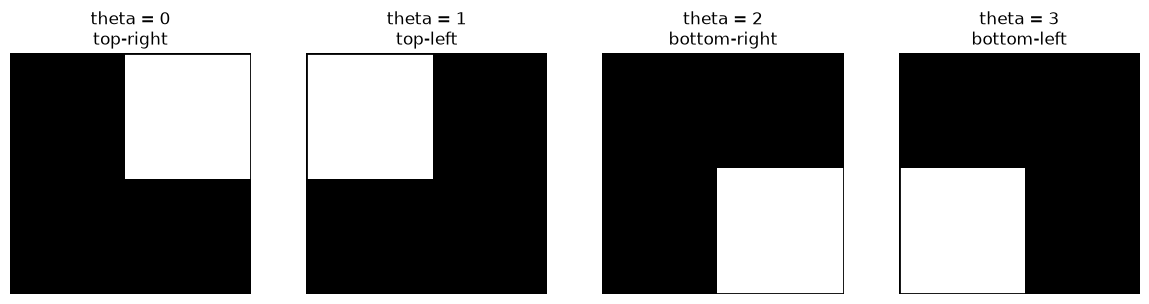

In [14]:
h = 10
M = 2*h + 1

fig, ax = plt.subplots(1, 4, figsize=(12, 3))

for theta in range(4):
    w = np.zeros((M, M))

    if theta == 0:
        # top-right quadrant
        w[:h+1, h:] = 1
        title = "theta = 0\ntop-right"

    elif theta == 1:
        # top-left quadrant
        w[:h+1, :h+1] = 1
        title = "theta = 1\ntop-left"

    elif theta == 2:
        # bottom-right quadrant
        w[h:, h:] = 1
        title = "theta = 2\nbottom-right"

    elif theta == 3:
        # bottom-left quadrant
        w[h:, :h+1] = 1
        title = "theta = 3\nbottom-left"

    ax[theta].imshow(w, cmap="gray", origin="upper")

    border = patches.Rectangle(
        (-0.5, -0.5),
        M,
        M,
        linewidth=2,
        edgecolor="black",
        facecolor="none"
    )
    ax[theta].add_patch(border)

    ax[theta].set_title(title)
    ax[theta].axis("off")

plt.tight_layout()
plt.show()

Initialize all the variables

In [15]:
# initialize the estimate for each scale
yhat = np.zeros(img.shape)

# initialize the matrix of the aggregation weights
weights = np.zeros(img.shape)

# store the directional estimates and selected scales for visualization
all_yhat_theta = []
all_best_scale = []

Use the LPA-ICI to compute find the best scale for each direction and compute the finale estimates

In [16]:
# loop over all the directions
for theta in all_theta:
    # initialize the estimate for the direction theta
    yhat_theta = np.zeros(img.shape)
    # initialize the matrix all the variances for the direction theta
    var_theta = np.zeros(img.shape)
    # initialize the matrix with the best scale
    best_scale = np.zeros(shape=img.shape)

    # initialize the lower and upper bounds matrices
    lower_bounds = - np.inf * np.ones(shape=img.shape)
    upper_bounds = np.inf * np.ones(shape=img.shape)

    # loop over all scales
    all_g_theta = all_g[theta]

    for i, h in enumerate(all_h):
        g = all_g_theta[i]

        # compute the estimate for the scale h
        yhat_h = convolve2d(noisy_img, g, mode='same', boundary='symm')

        var_h = sigma_noise**2 * np.linalg.norm(g)**2

        # compute the lower and upper bound of the confidence interval for the scale h
        lb = yhat_h - Gamma * np.sqrt(var_h)
        ub = yhat_h + Gamma * np.sqrt(var_h)

        # update the lower and upper bounds
        lower_bounds = np.maximum(lower_bounds, lb)
        upper_bounds = np.minimum(upper_bounds, ub)

        # detect pixels where the ICI intersection becomes empty and fix their best scale
        for r in range(img.shape[0]):
            for c in range(img.shape[1]):
                if lower_bounds[r, c] > upper_bounds[r, c] and best_scale[r, c] == 0:
                    # if the intersection fails at the first scale, there is no previous estimate available
                    if i == 0:
                        best_scale[r, c] = h
                        yhat_theta[r, c] = yhat_h[r, c]
                        var_theta[r, c] = var_h
                    # the current scale is too large, so we select the previous one as the best scale
                    else:
                        # select the previous scale as the best scale
                        best_scale[r, c] = all_h[i - 1]
                        # keep the previous estimate and variance
                        yhat_theta[r, c] = yhat_h_old[r, c]  
                        var_theta[r, c] = var_old

        yhat_h_old = yhat_h.copy()
        var_old = var_h

    # recompute the estimate for the largest scale
    yhat_h = convolve2d(noisy_img, all_g_theta[-1], mode='same', boundary='symm')
    var_h = sigma_noise**2 * np.linalg.norm(all_g_theta[-1])**2

    # for pixels where the ICI intersection never became empty, select the largest scale and use its estimate
    for r, c in np.ndindex(best_scale.shape):
        # pixels for which the ICI rule never failed still have best_scale equal to 0
        if best_scale[r, c] == 0:
            # use the largest scale as the best scale
            best_scale[r, c] = all_h[-1]
            # update the estimate and variance using the largest scale
            yhat_theta[r, c] = yhat_h[r, c]
            var_theta[r, c] = var_h
            
    # store the estimate and best scale for this direction
    all_yhat_theta.append(yhat_theta.copy())
    all_best_scale.append(best_scale.copy())

    # update the estimates and the weights
    yhat += yhat_theta / var_theta
    weights += 1 / var_theta

# compute the final estimates
yhat = yhat / weights

Compute the PSNR

In [17]:
psnr = 10 * np.log10(1 / np.mean((img - yhat)**2))

Text(0.5, 1.0, 'LPA-ICI estimate, PSNR = 27.15')

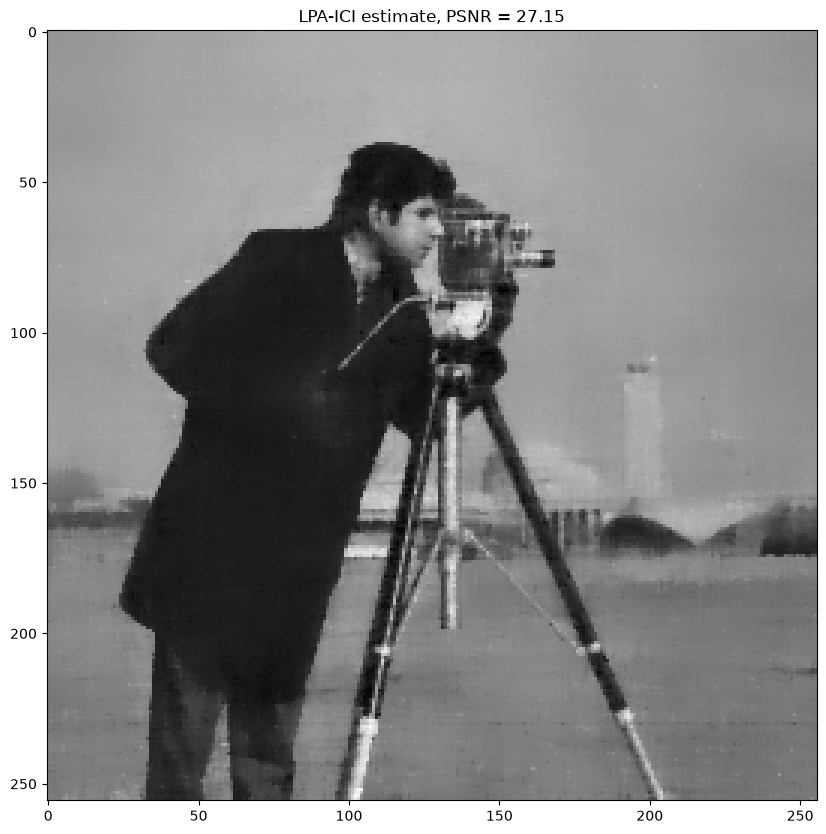

In [18]:
plt.figure(figsize=(10,10))
plt.imshow(yhat, cmap='gray')
plt.title(f'LPA-ICI estimate, PSNR = {psnr:.2f}')

Visualize all directional estimates, kernel supports, and selected scales

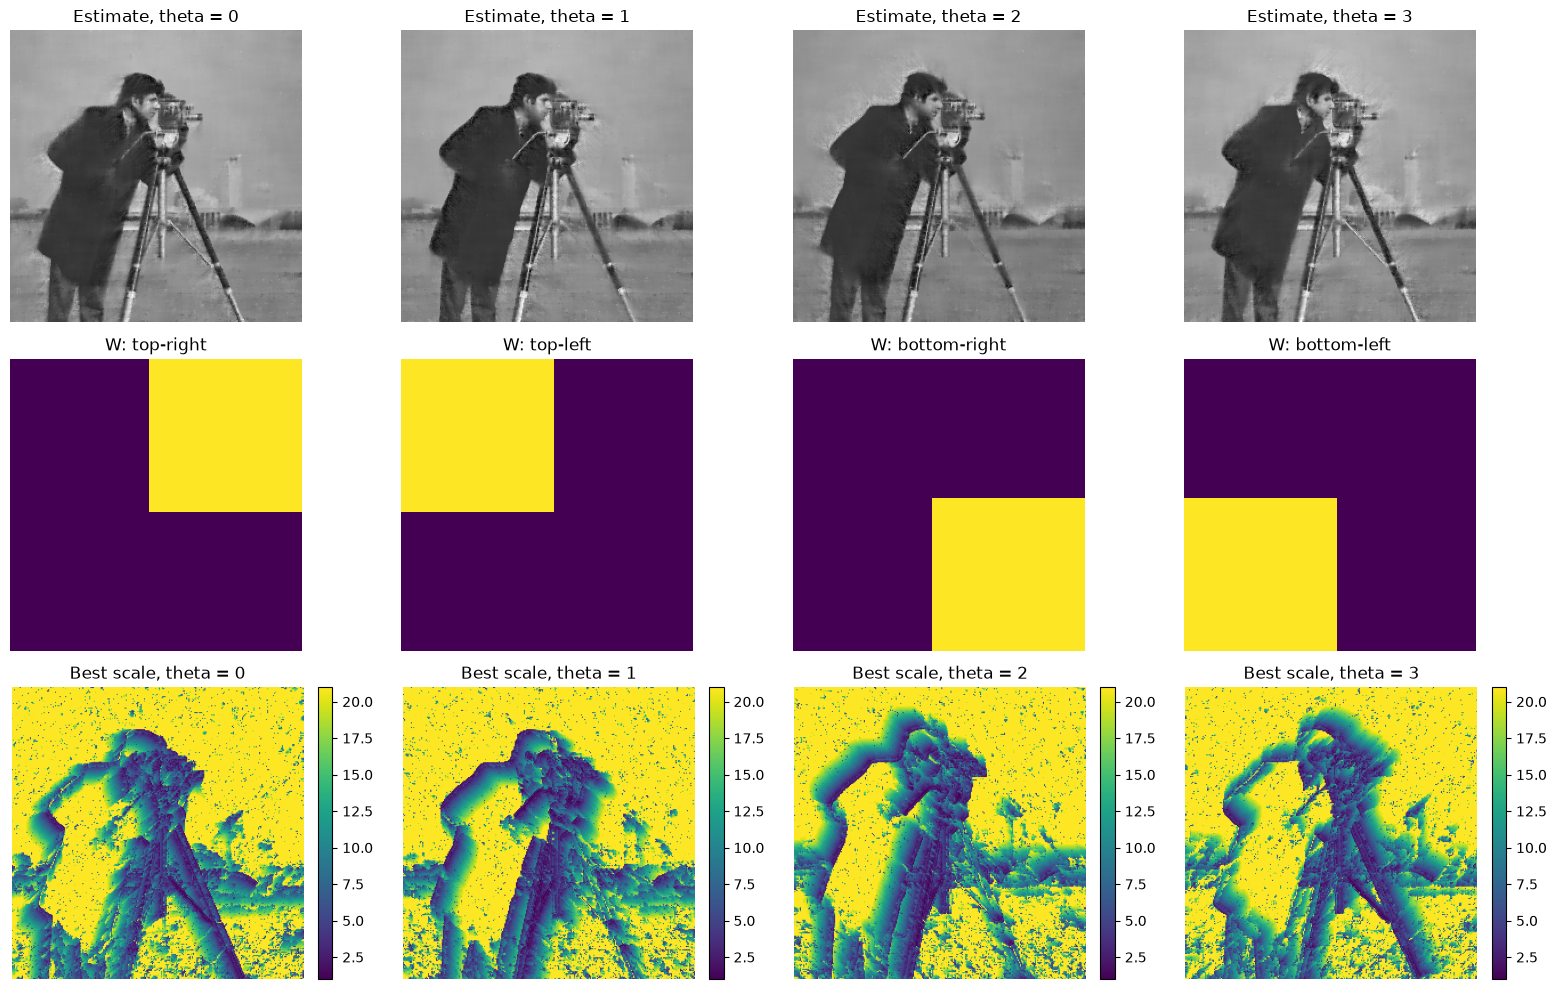

In [19]:
# choose the scale used only to display the directional masks W
h_to_show = 10

# labels for the directional supports
theta_titles = {
    0: 'top-right',
    1: 'top-left',
    2: 'bottom-right',
    3: 'bottom-left'
}

def make_directional_mask(theta, h):
    M = 2*h + 1
    w = np.zeros((M, M))

    if theta == 0:
        # top-right quadrant
        w[:h+1, h:] = 1
    elif theta == 1:
        # top-left quadrant
        w[:h+1, :h+1] = 1
    elif theta == 2:
        # bottom-right quadrant
        w[h:, h:] = 1
    elif theta == 3:
        # bottom-left quadrant
        w[h:, :h+1] = 1

    return w

fig, ax = plt.subplots(3, len(all_theta), figsize=(4*len(all_theta), 10))

for col, theta in enumerate(all_theta):
    w = make_directional_mask(theta, h_to_show)

    # show the estimate obtained with the directional LPA-ICI for theta
    ax[0, col].imshow(all_yhat_theta[theta], cmap='gray')
    ax[0, col].set_title(f'Estimate, theta = {theta}')
    ax[0, col].axis('off')

    # show the directional support W used to build the kernels
    ax[1, col].imshow(w, cmap='viridis', origin='upper')
    ax[1, col].set_title(f'W: {theta_titles[theta]}')
    ax[1, col].axis('off')

    # show the selected scale for each pixel for this direction
    im = ax[2, col].imshow(all_best_scale[theta])
    ax[2, col].set_title(f'Best scale, theta = {theta}')
    ax[2, col].axis('off')
    fig.colorbar(im, ax=ax[2, col], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()